In [8]:
import pandas as pd 
features = pd.read_csv('data_A1/X_knn_SVM.csv')
target = pd.read_csv('data_A1/y_knn_SVM.csv')

In [9]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

### SVM Base Training

In [10]:
# The focus lies again on Diagnosis as target 
target.head()
target = target["Diagnosis"]


X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42))
])


pipe.fit(X_train, y_train)
y_pred_svm = pipe.predict(X_test)
y_score_svm = pipe.predict_proba(X_test)[:, 1]


#### Classification Report, Confusion Matrix & ROC-AUC Score

In [11]:
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_svm))
print()
print("Classification Report:\n", classification_report(y_test, y_pred_svm, digits=3))
print()
print("ROC-AUC:", round(roc_auc_score(y_test, y_score_svm), 3))

Confusion Matrix:
 [[57  6]
 [ 7 85]]

Classification Report:
               precision    recall  f1-score   support

         0.0      0.891     0.905     0.898        63
         1.0      0.934     0.924     0.929        92

    accuracy                          0.916       155
   macro avg      0.912     0.914     0.913       155
weighted avg      0.916     0.916     0.916       155


ROC-AUC: 0.961


### SVM Tuned

In [12]:

param_grid_svm = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__kernel": ["linear", "rbf"],
    "svm__gamma": ["scale", "auto"]
}

grid_search_svm = GridSearchCV(
    pipe,
    param_grid_svm,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search_svm.fit(X_train, y_train)

print("Best parameters:", grid_search_svm.best_params_)
print("Best CV ROC-AUC:", round(grid_search_svm.best_score_, 3))

Best parameters: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best CV ROC-AUC: 0.975


In [13]:
best_svm = grid_search_svm.best_estimator_

y_pred_svm_tuned = best_svm.predict(X_test)
y_score_svm_tuned = best_svm.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_tuned))
print()
print("Classification Report:\n", classification_report(y_test, y_pred_svm_tuned, digits=3))
print("Tuned ROC-AUC:", round(roc_auc_score(y_test, y_score_svm_tuned), 3))

Confusion Matrix:
 [[55  8]
 [ 8 84]]

Classification Report:
               precision    recall  f1-score   support

         0.0      0.873     0.873     0.873        63
         1.0      0.913     0.913     0.913        92

    accuracy                          0.897       155
   macro avg      0.893     0.893     0.893       155
weighted avg      0.897     0.897     0.897       155

Tuned ROC-AUC: 0.96


#### ROC Curve Tuned vs Baseline

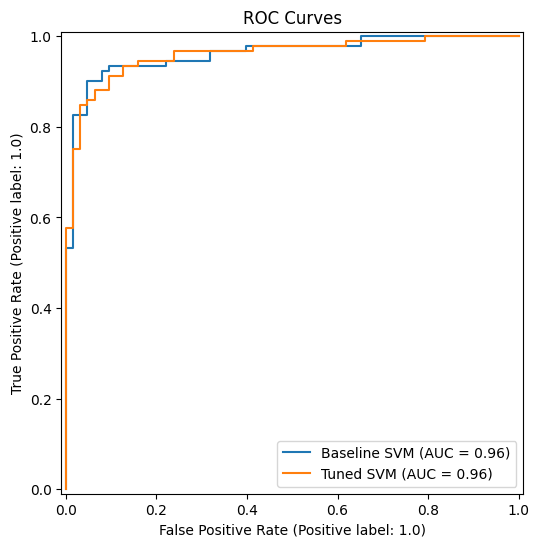

In [14]:
fig, ax = plt.subplots(figsize=(7,6))

RocCurveDisplay.from_estimator(
    pipe,
    X_test,
    y_test,
    ax=ax,
    name="Baseline SVM"
)

RocCurveDisplay.from_estimator(
    best_svm,
    X_test,
    y_test,
    ax=ax,
    name="Tuned SVM"
)

plt.title("ROC Curves")
plt.show()